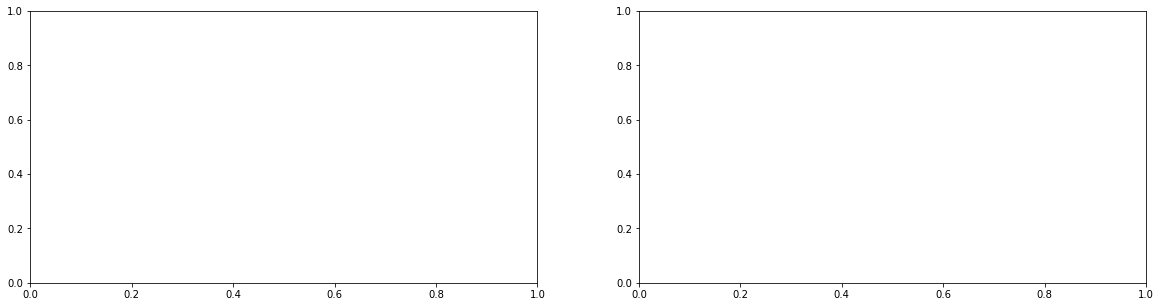

In [1]:
import os
import sys
import time
import copy
sys.path.append('..')

import numpy as np
import math
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

import json

import fnmatch
import re
from itertools import product, groupby

# device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device = 'cpu'

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

fig, ax = plt.subplots(1, 2, figsize=(20,5.0))

In [4]:
dataset = 'tinystories'
path = f'{dataset}/correlations/'
tokenizer = 'BPE8192'
split = 'train'
max_dist = 1025
prefix = f'corr-norms-v-data_{dataset}.{tokenizer}_nmax{max_dist}'

d_list = [1,2,3,4,6,8,12,16,24,32,48,64,96,128,192,256,512]
onorm_list = []
fnorm_list = []

for i, dist in enumerate(d_list):

    norms = torch.load(path + prefix + f"_n{dist}.pt")
    print(dist, norms['op'][-1], norms['fro'][-1])
    onorm_list.append(norms['op'][-1])
    fnorm_list.append(norms['fro'][-1])

1 0.020652365 0.03123354851290945
2 0.013330108 0.020913148068743892
3 0.011288408 0.015546046489086314
4 0.0075750095 0.011318319286048335
6 0.004561715 0.007304043599616931
8 0.0025285503 0.0049797547067538805
12 0.0024443534 0.0033751002941986765
16 0.0010349884 0.0019601087258545695
24 0.000745961 0.0014313351326235267
32 0.00059757015 0.0011293398611161188
48 0.0005583425 0.0009681850013054728
64 0.0005051123 0.0008506477208017724
96 0.00041032312 0.00066293264495687
128 0.000384116 0.0005507029220628658
192 0.00031273408 0.0004015674049184964
256 0.00018946675 0.0002581234179876653
512 5.228961e-05 8.150795694793194e-05


## Extract $\beta$ from a power-law fit of $\| C(n) \|_{\mathrm{op}}$ vs $n$

In [13]:
from scipy.stats import t

# select distances <200 as almost all stories have less than 200 tokens
end = 15
print(d_list[:end])

fit_f = np.polyfit(np.log(np.array(d_list[:end])), np.log(np.array(fnorm_list[:end])), deg=1, cov=True)
print('F norm fit:', fit_f)

fit_o, cov = np.polyfit(np.log(np.array(d_list[:end])), np.log(np.array(onorm_list[:end])), deg=1, cov=True)
print('op norm fit:', fit_o) 

m, b = fit_o
perr = np.sqrt(np.diag(cov))

print("slope =", m, "+/-", perr[0])
print("intercept =", b, "+/-", perr[1])

n = len(onorm_list[:end])
p = len(fit_o)
dof = n - p
tval = t.ppf(0.975, dof)

ci_m = (m - tval * perr[0], m + tval * perr[0])
ci_b = (b - tval * perr[1], b + tval * perr[1])

print("95% CI slope:", ci_m)
print("95% CI intercept:", ci_b)

[1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64, 96, 128, 192]
F norm fit: (array([-0.88341744, -3.42110372]), array([[ 0.00124997, -0.00347114],
       [-0.00347114,  0.01261776]]))
op norm fit: [-0.88429318 -3.89501896]
slope = -0.8842931832865071 +/- 0.055409685212416876
intercept = -3.8950189619035207 +/- 0.17604607748975107
95% CI slope: (-1.0039985304837837, -0.7645878360892304)
95% CI intercept: (-4.275343389805285, -3.5146945340017557)


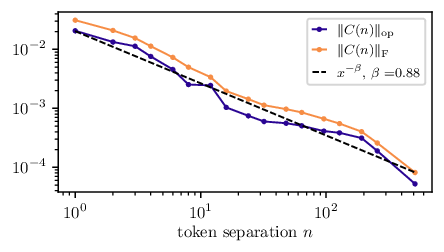

In [8]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.2), dpi=120)

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
u = np.linspace(0, 1, 6)              # [0, 1]
colors2 = cmap(u)                     # shape (4,4) RGBA

ax.plot(d_list, onorm_list, color=colors2[0], marker='.', label=r'$\| C(n) \|_{\mathrm{op}}$')
ax.plot(d_list, fnorm_list, color=colors2[4], marker='.', label=r'$\| C(n) \|_{\mathrm{F}}$')
ax.plot(d_list, [math.exp(fit_o[1])*d**fit_o[0] for d in d_list], 'k--',label=r'$x^{-\beta}$, $\beta=$'+'{:03.2f}'.format(-fit_o[0]))
# ax.plot(d_list, [math.exp(fit_o[1])*d**(-0.79) for d in d_list], 'r--')
# ax.plot(d_list, [math.exp(fit_o[1])*d**(-0.97) for d in d_list], 'r--')


ax.legend(fontsize=8, handlelength=1)
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'token separation $n$', fontsize=10)

# ticks  = [1, 2, 3, 4]
# labels = ["1", "2", "3", "4"]  # must match length/order
# ax.set_yticks(ticks)
# ax.set_yticklabels(labels)

fig.tight_layout()

In [15]:
fig.savefig(f'tinystories/'+f'C_n__{dataset}.{tokenizer}.pdf',  bbox_inches="tight")

### Plot with standard error

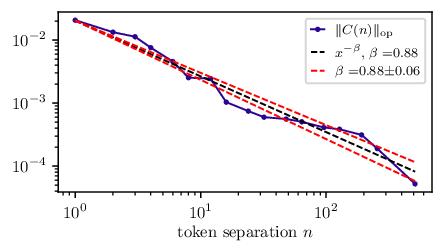

In [21]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.2), dpi=120)

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
u = np.linspace(0, 1, 6)              # [0, 1]
colors2 = cmap(u)                     # shape (4,4) RGBA

ax.plot(d_list, onorm_list, color=colors2[0], marker='.', label=r'$\| C(n) \|_{\mathrm{op}}$')
# ax.plot(d_list, fnorm_list, color=colors2[4], marker='.', label=r'$\| C(n) \|_{\mathrm{F}}$')
ax.plot(d_list, [math.exp(fit_o[1])*d**fit_o[0] for d in d_list], 'k--',label=r'$x^{-\beta}$, $\beta=$'+'{:03.2f}'.format(-fit_o[0]))
ax.plot(d_list, [math.exp(fit_o[1])*d**(fit_o[0]-perr[0]) for d in d_list], 'r--')
ax.plot(d_list, [math.exp(fit_o[1])*d**(fit_o[0]+perr[0]) for d in d_list], 'r--', label=r'$\beta=$'+'{:03.2f}'.format(-fit_o[0])+'$\pm$'+'{:03.2f}'.format(perr[0]))


ax.legend(fontsize=8, handlelength=1)
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'token separation $n$', fontsize=10)

# ticks  = [1, 2, 3, 4]
# labels = ["1", "2", "3", "4"]  # must match length/order
# ax.set_yticks(ticks)
# ax.set_yticklabels(labels)

fig.tight_layout()

In [22]:
fig.savefig(f'tinystories/'+f'C_n__{dataset}.{tokenizer}_error.pdf',  bbox_inches="tight")

## Compute error via bootstrap

In [20]:
def fit_powerlaw(x, y, n_bootstrap=1000, rng=None):
    """
    Fit y = a * x^alpha on log-log scale.
    Returns alpha with two error estimates:
      - se_cov:  standard error from polyfit's covariance matrix
      - se_boot: standard error from bootstrap resampling
    """
    rng = np.random.default_rng(rng)
    lx, ly = np.log(x), np.log(y)

    # ── Covariance-based SE ───────────────────────────────────────────────────
    coeffs, cov = np.polyfit(lx, ly, deg=1, cov=True)
    alpha    = coeffs[0]          # power-law exponent
    se_cov   = np.sqrt(cov[0, 0]) # SE on the slope

    # ── Bootstrap SE ─────────────────────────────────────────────────────────
    idx       = np.arange(len(x))
    boot_alphas = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        sample = rng.choice(idx, size=len(idx), replace=True)
        boot_alphas[i] = np.polyfit(lx[sample], ly[sample], deg=1)[0]

    se_boot = boot_alphas.std(ddof=1)  # ddof=1 → unbiased sample std

    return alpha, se_cov, se_boot, boot_alphas


# ── Example ───────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

x = np.array(d_list[:end])
y = np.array(onorm_list[:end])
alpha, se_cov, se_boot, boot_dist = fit_powerlaw(x, y, rng=rng)

print(f"alpha       = {alpha:.4f}")
print(f"SE (cov)    = {se_cov:.4f}   → {alpha:.4f} ± {se_cov:.4f}")
print(f"SE (boot)   = {se_boot:.4f}  → {alpha:.4f} ± {se_boot:.4f}")

# Bootstrap also gives you percentile CIs for free (asymmetric if needed):
lo, hi = np.percentile(boot_dist, [2.5, 97.5])
print(f"95% boot CI = [{lo:.4f}, {hi:.4f}]")

alpha       = -0.8843
SE (cov)    = 0.0554   → -0.8843 ± 0.0554
SE (boot)   = 0.0607  → -0.8843 ± 0.0607
95% boot CI = [-1.0256, -0.7826]
